# 6장 실습 ③ — 배치 정규화가 하는 다른 일

**TensorFlow 판**

5장 §5.4에서 미뤄 둔 과제를 닫습니다.
*"깊어질수록 견딜 수 있는 학습률의 폭이 좁아진다"* — 배치 정규화가 그 폭을
다시 넓혀 주는지 확인합니다.

## 6.0 준비

In [1]:
try:
    import dlbook
except ImportError:
    !pip install -q "dlbook @ git+https://github.com/dhrim/deep-learning-in-one-semester.git"
    import dlbook

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import dlbook
from dlbook import data, metrics, plot

dlbook.set_seed(42)
plot.use_korean()
print(dlbook.versions())

{'python': '3.12.3', 'numpy': '2.1.3', 'keras': '3.15.1', 'tensorflow': '2.21.0', 'torch': '-', 'keras_backend': 'tensorflow'}


## 6.1 실험대 — 잡음을 키운 소용돌이

5장에서는 잡음 0.06을 썼습니다. 여기서는 **0.25**로 키웁니다.
잡음이 있어야 *"잡음까지 외우는"* 현상이 보이기 때문입니다.

구분            개수  입력 shape
train        960  (2,)
val          320  (2,)
test         320  (2,)


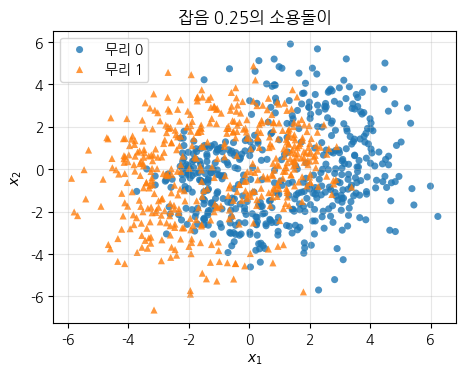

In [3]:
def make(n, seed=42, noise=0.25):
    """잡음을 0.25로 키운다 — 과적합이 눈에 보이도록."""
    x, y = data.spirals(n, seed=seed, noise=noise)
    return data.split(x, y, val_ratio=0.2, test_ratio=0.2, seed=seed)

s = make(1600)
print(s.summary())
plot.scatter2d(s.x_train, s.y_train, class_names=("무리 0", "무리 1"),
               xlabel="$x_1$", ylabel="$x_2$", title="잡음 0.25의 소용돌이")
plt.show()

## 6.2 학습 함수 — 여기만 판마다 다릅니다

드롭아웃·L2·배치 정규화·조기 종료를 옵션으로 받습니다.
**이 아래의 모든 셀은 세 판이 같습니다.**

In [4]:
import tensorflow as tf

dlbook.set_seed(42)

def train(split, units=(256, 256, 256), drop=0.0, l2=0.0, bn=False,
          act="relu", lr=0.001, epochs=200, bs=32, early=0, seed=42):
    """모델을 만들어 학습시키고 (학습 정확도, 시험 정확도, history)를 돌려준다.

    이 함수 하나만 판마다 다르다. 아래의 모든 실험 셀은 세 판이 같다.
    """
    dlbook.set_seed(seed)
    reg = tf.keras.regularizers.l2(l2) if l2 else None
    ls = [tf.keras.layers.Input(shape=(2,))]
    for u in units:
        ls.append(tf.keras.layers.Dense(u, activation=None if bn else act,
                                        kernel_regularizer=reg))
        if bn:
            ls += [tf.keras.layers.BatchNormalization(),
                   tf.keras.layers.Activation(act)]
        if drop:
            ls.append(tf.keras.layers.Dropout(drop))
    ls.append(tf.keras.layers.Dense(1, activation="sigmoid"))
    model = tf.keras.Sequential(ls)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss="binary_crossentropy", metrics=["accuracy"])
    cbs = ([tf.keras.callbacks.EarlyStopping(patience=early,
                                             restore_best_weights=True)]
           if early else [])
    h = model.fit(split.x_train, split.y_train,
                  validation_data=(split.x_val, split.y_val),
                  epochs=dlbook.smoke.epochs(epochs), batch_size=bs,
                  verbose=0, callbacks=cbs)
    def acc(xa, ya):
        p = (model.predict(xa, verbose=0).reshape(-1) > 0.5).astype("int64")
        return metrics.accuracy(ya, p)
    return acc(split.x_train, split.y_train), acc(split.x_test, split.y_test), h.history

## 6.3 20층 ReLU에 배치 정규화를 붙인다

5장 §5.4에서 20층 ReLU가 lr=0.01에서 0.500으로 무너졌습니다.

In [5]:
# 5장 §5.4의 미결 과제 — 배치 정규화가 학습률 예민함을 없애는가.
s_big = make(1600, noise=0.06)          # 5장과 같은 조건
lrs = [0.001, 0.01] if dlbook.smoke.is_smoke() else [0.001, 0.01, 0.03]
depth = 20

print(f"은닉층 {depth}개, ReLU, 60 epoch")
print(f"{'':<18}" + "".join(f"{'lr=' + str(l):>11}" for l in lrs))
for bn, name in ((False, "배치정규화 없음"), (True, "배치정규화 있음")):
    row = []
    for lr in lrs:
        _, te, _ = train(s_big, units=(32,) * depth, bn=bn, lr=lr, epochs=60)
        row.append(te)
        dlbook.record(f"ch06_bn{int(bn)}_d{depth}_lr{lr}_acc", te)
    print(f"{name:<18}" + "".join(f"{v:>11.3f}" for v in row))

print()
print("→ 배치 정규화는 성능을 올린 것이 아니라 **학습률에 대한 예민함을 없앤** 것입니다.")

은닉층 20개, ReLU, 60 epoch
                     lr=0.001    lr=0.01    lr=0.03


ch06_bn0_d20_lr0.001_acc = 0.9969


ch06_bn0_d20_lr0.01_acc = 0.5000


ch06_bn0_d20_lr0.03_acc = 0.5000
배치정규화 없음                0.997      0.500      0.500


ch06_bn1_d20_lr0.001_acc = 1.0000


ch06_bn1_d20_lr0.01_acc = 1.0000


ch06_bn1_d20_lr0.03_acc = 0.9875
배치정규화 있음                1.000      1.000      0.988

→ 배치 정규화는 성능을 올린 것이 아니라 **학습률에 대한 예민함을 없앤** 것입니다.


## 6.4 그럼 시그모이드도 살릴 수 있나

5장의 진짜 벽은 시그모이드였습니다. 10층에서 어떤 학습률로도 0.72를
못 넘었습니다.

In [6]:
# 그럼 기울기 소실도 고칠 수 있나. 10층 시그모이드로 확인한다.
lrs = [0.001, 0.01]
print(f"은닉층 10개, 시그모이드, 60 epoch")
print(f"{'':<18}" + "".join(f"{'lr=' + str(l):>11}" for l in lrs))
for bn, name in ((False, "배치정규화 없음"), (True, "배치정규화 있음")):
    row = []
    for lr in lrs:
        _, te, _ = train(s_big, units=(32,) * 10, act="sigmoid", bn=bn,
                         lr=lr, epochs=60)
        row.append(te)
        dlbook.record(f"ch06_bnsig{int(bn)}_lr{lr}_acc", te)
    print(f"{name:<18}" + "".join(f"{v:>11.3f}" for v in row))

print()
print("→ 나아지지만 ReLU의 1.000에는 못 미칩니다.")
print("→ **배치 정규화는 기울기 소실을 완화할 뿐 해결하지 못합니다.**")
print("→ 근본 해법은 활성화 함수를 바꾸는 것입니다.")

은닉층 10개, 시그모이드, 60 epoch
                     lr=0.001    lr=0.01


ch06_bnsig0_lr0.001_acc = 0.7094


ch06_bnsig0_lr0.01_acc = 0.5000
배치정규화 없음                0.709      0.500


ch06_bnsig1_lr0.001_acc = 0.8187


ch06_bnsig1_lr0.01_acc = 0.7969
배치정규화 있음                0.819      0.797

→ 나아지지만 ReLU의 1.000에는 못 미칩니다.
→ **배치 정규화는 기울기 소실을 완화할 뿐 해결하지 못합니다.**
→ 근본 해법은 활성화 함수를 바꾸는 것입니다.


## 정리

- **배치 정규화의 진짜 일은 규제가 아닙니다.** 20층 ReLU를 lr=0.01에서
  0.500 → 1.000으로 되살립니다. **학습률에 대한 예민함을 없앱니다.**
- **다만 기울기 소실은 완화할 뿐 해결하지 못합니다.** 10층 시그모이드는
  0.71 → 0.82에 그칩니다. ReLU의 1.000과는 거리가 멉니다.
- **근본 해법은 활성화 함수를 바꾸는 것입니다.** 배치 정규화는 그 위에
  얹는 것이지 대신하는 것이 아닙니다.
- 층이 수십을 넘으면 배치 정규화로도 부족합니다. → **잔차 연결**, 9장.

### 연습

1. `Dense → 활성화 → BN` 순서로 바꾸면 성능이 달라집니까.
2. 배치 사이즈를 아주 작게(4) 주면 배치 정규화가 어떻게 됩니까. 왜 그렇습니까.
3. 30층 ReLU + 배치 정규화는 어디까지 버팁니까.